# BELLABEAT CASE STUDY: SQL ANALYSIS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sqlite3

In [3]:
from pathlib import Path

In [4]:
CLEAN_PATH = Path(r"E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data")
SQL_PATH = CLEAN_PATH / "bellabeat_sqlite.db"
print(f"📊 Loading from: {CLEAN_PATH / '04_daily_master_final.csv'}")
print(f"💾 SQLite DB: {SQL_PATH}")

📊 Loading from: E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\04_daily_master_final.csv
💾 SQLite DB: E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\bellabeat_sqlite.db


# CREATE STAR SCHEMA DATABASE

In [5]:
# Connect to SQLite
conn = sqlite3.connect(SQL_PATH)

# Load cleaned master data
daily_master = pd.read_csv(CLEAN_PATH / '04_daily_master_final.csv')
print(f"📊 Loaded: {len(daily_master):,} rows, {daily_master['Id'].nunique():,} users")

📊 Loaded: 860 rows, 33 users


In [6]:
# Create tables (STAR SCHEMA)
daily_master.to_sql('fact_daily_activity', conn, if_exists='replace', index=False)
print("✅ fact_daily_activity table created")

✅ fact_daily_activity table created


In [7]:
# Create dimension tables
daily_master[['Id']].drop_duplicates().to_sql('dim_users', conn, if_exists='replace', index=False)

33

In [8]:
# Add user summary stats
user_stats = daily_master.groupby('Id').agg({
    'TotalSteps': ['mean', 'count'],
    'Calories': 'mean',
    'activity_date': ['min', 'max']
}).round(2).reset_index()
user_stats.columns = ['Id', 'avg_steps', 'tracking_days', 'avg_calories', 'first_date', 'last_date']
user_stats.to_sql('dim_user_summary', conn, if_exists='replace', index=False)
print("✅ Dimension tables created")

✅ Dimension tables created


# KEY BUSINESS QUERIES

In [9]:
# Query 1: WEEKDAY ACTIVITY PATTERNS (matches your chart!)
q1 = """
SELECT 
    strftime('%w', activity_date) as weekday_num,
    CASE strftime('%w', activity_date)
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday' 
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
        WHEN '0' THEN 'Sunday'
    END as weekday_name,
    ROUND(AVG(TotalSteps), 0) as avg_steps,
    ROUND(AVG(Calories), 0) as avg_calories,
    COUNT(*) as records
FROM fact_daily_activity 
WHERE tracker_not_worn = 0
GROUP BY weekday_num, weekday_name
ORDER BY weekday_num
"""
weekday_analysis = pd.read_sql_query(q1, conn)
print("\n📊 Q1: Steps by Weekday")
print(weekday_analysis)


📊 Q1: Steps by Weekday
  weekday_num weekday_name  avg_steps  avg_calories  records
0           0       Sunday     7406.0        2306.0      108
1           1       Monday     8488.0        2381.0      109
2           2      Tuesday     8861.0        2416.0      136
3           3    Wednesday     8191.0        2338.0      138
4           4     Thursday     8064.0        2256.0      135
5           5       Friday     7821.0        2352.0      120
6           6     Saturday     8821.0        2408.0      114


In [10]:
# Query 2: USER SEGMENTATION
q2 = """
WITH user_segments AS (
    SELECT 
        Id,
        ROUND(AVG(TotalSteps), 0) as avg_daily_steps,
        CASE 
            WHEN AVG(TotalSteps) >= 10000 THEN 'Very Active'
            WHEN AVG(TotalSteps) >= 7500 THEN 'Moderately Active'
            WHEN AVG(TotalSteps) >= 5000 THEN 'Lightly Active'
            ELSE 'Sedentary'
        END as activity_segment,
        COUNT(*) as tracking_days
    FROM fact_daily_activity
    GROUP BY Id
)
SELECT 
    activity_segment,
    COUNT(*) as user_count,
    ROUND(AVG(avg_daily_steps), 0) as avg_steps,
    AVG(tracking_days) as avg_days_tracked
FROM user_segments
GROUP BY activity_segment
ORDER BY avg_steps DESC
"""
user_segments = pd.read_sql_query(q2, conn)
print("\n👥 Q2: User Activity Segments")
print(user_segments)


👥 Q2: User Activity Segments
    activity_segment  user_count  avg_steps  avg_days_tracked
0        Very Active           7    12613.0         29.714286
1  Moderately Active          11     8685.0         28.090909
2     Lightly Active           7     6497.0         22.428571
3          Sedentary           8     3767.0         23.250000


In [11]:
# Query 3: SLEEP CORRELATION
q3 = """
SELECT 
    ROUND(AVG(TotalSteps), 0) as avg_steps,
    ROUND(AVG(TotalMinutesAsleep)/60.0, 1) as avg_sleep_hours,
    COUNT(*) as days_with_sleep,
    ROUND(AVG(TotalMinutesAsleep), 0) as avg_sleep_minutes
FROM fact_daily_activity 
WHERE TotalMinutesAsleep IS NOT NULL 
  AND TotalMinutesAsleep > 0
"""
sleep_corr = pd.read_sql_query(q3, conn)
print("\n😴 Q3: Sleep Analysis")
print(sleep_corr)


😴 Q3: Sleep Analysis
   avg_steps  avg_sleep_hours  days_with_sleep  avg_sleep_minutes
0     8515.0              7.0              410              419.0


In [12]:
# Query 4: TOP 5 MOST ACTIVE USERS
q4 = """
SELECT 
    Id,
    ROUND(AVG(TotalSteps), 0) as avg_steps,
    ROUND(AVG(Calories), 0) as avg_calories,
    COUNT(*) as tracking_days,
    ROUND(AVG(SedentaryMinutes), 0) as avg_sedentary_min
FROM fact_daily_activity
GROUP BY Id
ORDER BY avg_steps DESC
LIMIT 5
"""
top_users = pd.read_sql_query(q4, conn)
print("\n🥇 Q4: Top 5 Most Active Users")
print(top_users)


🥇 Q4: Top 5 Most Active Users
           Id  avg_steps  avg_calories  tracking_days  avg_sedentary_min
0  8877689391    16040.0        3420.0             31             1113.0
1  8053475328    14763.0        2946.0             31             1148.0
2  1503960366    12521.0        1877.0             30              828.0
3  7007744171    11776.0        2583.0             25             1040.0
4  2022484408    11371.0        2510.0             31             1113.0


In [16]:
# Query 5: TRACKER ADHERENCE
q5 = """
WITH user_adherence AS (
    SELECT 
        Id,
        COUNT(*) as tracking_days
    FROM fact_daily_activity
    WHERE tracker_not_worn = 0
    GROUP BY Id
),
adherence_summary AS (
    SELECT 
        CASE 
            WHEN tracking_days >= 25 THEN 'High Adherence (25+ days)'
            WHEN tracking_days >= 15 THEN 'Medium Adherence (15-24 days)'
            WHEN tracking_days >= 7 THEN 'Low Adherence (7-14 days)'
            ELSE 'Poor Adherence (<7 days)'
        END as adherence_level,
        COUNT(*) as user_count,
        ROUND(AVG(tracking_days), 1) as avg_days_tracked,
        ROUND(AVG(tracking_days)*100.0 / 31, 1) as adherence_pct
    FROM user_adherence
    GROUP BY adherence_level
)
SELECT * FROM adherence_summary
ORDER BY avg_days_tracked DESC
"""
adherence = pd.read_sql_query(q5, conn)
print("\n📈 Q5: Tracker Adherence Analysis")
print(adherence)


📈 Q5: Tracker Adherence Analysis
                 adherence_level  user_count  avg_days_tracked  adherence_pct
0      High Adherence (25+ days)          23              29.7           95.9
1  Medium Adherence (15-24 days)           9              19.2           62.0
2       Poor Adherence (<7 days)           1               3.0            9.7


# VISUALIZATIONS

C:\Users\aniru\AppData\Local\Temp\ipykernel_7784\74599034.py:30: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aniru\AppData\Local\Temp\ipykernel_7784\74599034.py:31: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(SQL_PATH.with_suffix('.png'), dpi=300, bbox_inches='tight')
C:\Users\aniru\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


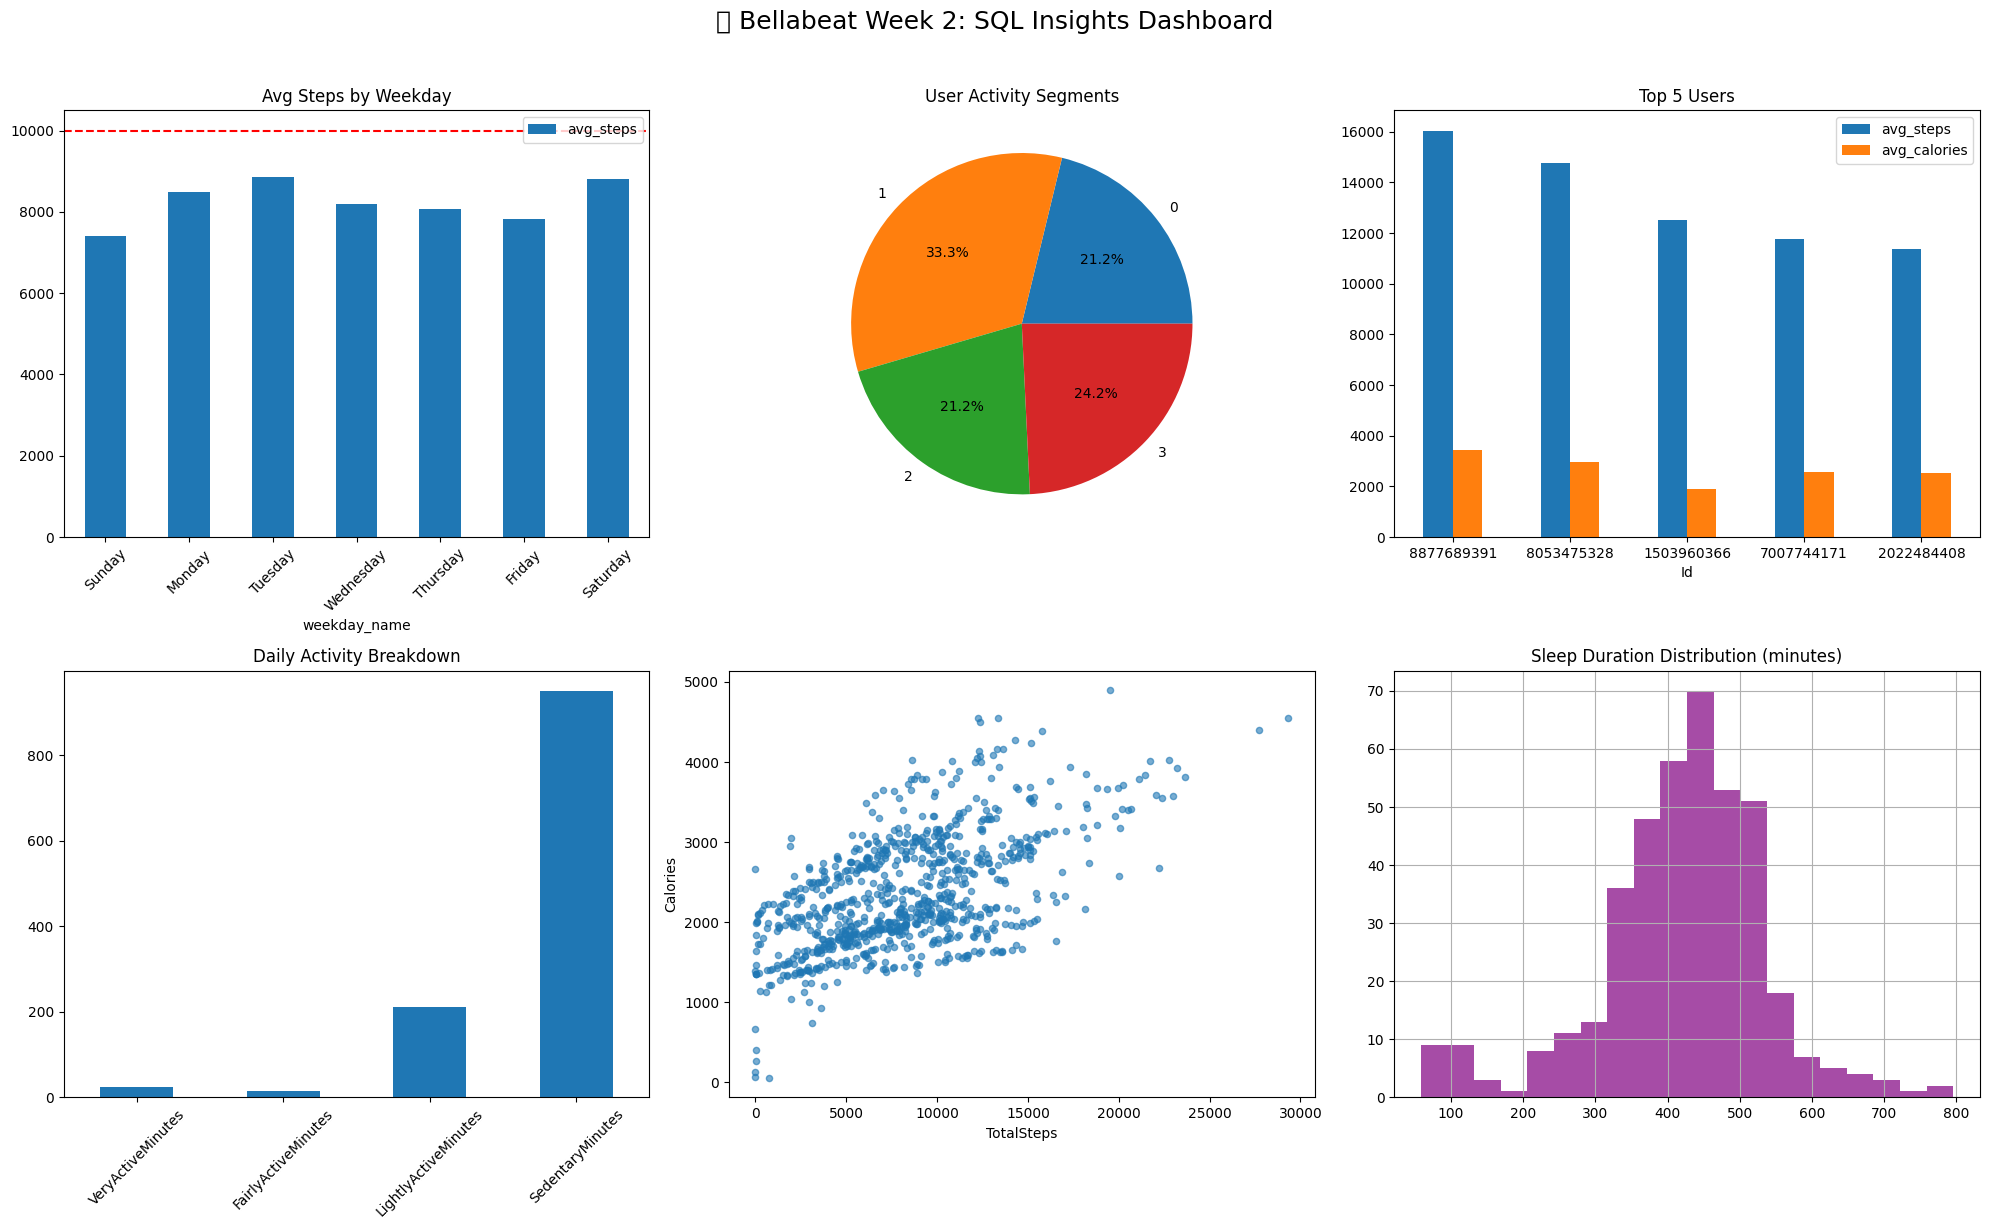

In [17]:

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🏆 Bellabeat Week 2: SQL Insights Dashboard', fontsize=18, y=1.02)

# 1. Steps by weekday
weekday_analysis.plot(x='weekday_name', y='avg_steps', kind='bar', ax=axes[0,0], title='Avg Steps by Weekday')
axes[0,0].axhline(10000, color='red', linestyle='--', label='CDC Goal')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. User segments pie
user_segments.plot(x='activity_segment', y='user_count', kind='pie', ax=axes[0,1], 
                  autopct='%1.1f%%', title='User Activity Segments', legend=False)

# 3. Top users bar
top_users.plot(x='Id', y=['avg_steps', 'avg_calories'], kind='bar', ax=axes[0,2], title='Top 5 Users')
axes[0,2].tick_params(axis='x', rotation=0)

# 4. Activity breakdown
activity_means = daily_master[['VeryActiveMinutes', 'FairlyActiveMinutes', 
                              'LightlyActiveMinutes', 'SedentaryMinutes']].mean()
activity_means.plot(kind='bar', ax=axes[1,0], title='Daily Activity Breakdown')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Calories vs Steps scatter
daily_master.plot(x='TotalSteps', y='Calories', kind='scatter', ax=axes[1,1], alpha=0.6)

# 6. Sleep distribution
daily_master['TotalMinutesAsleep'].hist(bins=20, ax=axes[1,2], alpha=0.7, color='purple')
axes[1,2].set_title('Sleep Duration Distribution (minutes)')

plt.tight_layout()
plt.savefig(SQL_PATH.with_suffix('.png'), dpi=300, bbox_inches='tight')
plt.show()


# EXPORT SQL RESULTS

In [21]:
# Save query results as CSV
weekday_analysis.to_csv(SQL_PATH.with_name('Phase2weekday_analysis'), index=False)
user_segments.to_csv(SQL_PATH.with_name('Phase2user_segments'), index=False)
top_users.to_csv(SQL_PATH.with_name('Phase2top_users'), index=False)

In [22]:
print("\n💾 Phase 2 FILES SAVED:")
print(f"   {SQL_PATH}")
print(f"   {SQL_PATH.with_name('Phase2weekday_analysis.csv')}")
print(f"   {SQL_PATH.with_name('Phase2user_segments.csv')}")


💾 Phase 2 FILES SAVED:
   E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\bellabeat_sqlite.db
   E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\Phase2weekday_analysis.csv
   E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\Phase2user_segments.csv


In [23]:
# Close connection
conn.close()

print("\n🎉 PHASE 2 COMPLETe")
print("✅ SQLite database with star schema")
print("✅ 5 business queries executed") 
print("✅ SQL insights dashboard generated")
print("✅ Ready for Week 3: Tableau!")


🎉 PHASE 2 COMPLETe
✅ SQLite database with star schema
✅ 5 business queries executed
✅ SQL insights dashboard generated
✅ Ready for Week 3: Tableau!
